# 06 · Correlative alignment of two maps

*Overlay a mechanical map and a second modality: the method behind mechanics↔microstructure correlation.*

> ⏱ **Runtime:** ~5 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** Al–Cu map (H and E channels)

### 🎯 What you'll learn
1. why two maps of the same area must be **registered** (aligned) before comparison,
2. **normalised cross-correlation (NCC)** as an alignment score,
3. how to recover a **rigid transform** (rotation + translation),
4. how to quantify **point-to-point agreement** with a **confusion matrix** and **Dice**.

### 🧭 What you need to know first
- The idea of a property map (notebook 00) and a confusion matrix (notebook 03).
- No deep learning needed here. This is classic image processing.

> 🔬 **Why this matters.** To say *"this mechanical zone is that phase/grain"* you must first put
> both maps on the **same grid**. Instruments never agree on pixel coordinates, so one map is
> shifted, rotated and scaled relative to the other. This notebook teaches the **exact registration
> pipeline** used for mechanics↔microstructure correlation, demonstrated by aligning two channels of
> the Al–Cu map (hardness `H` and modulus `E`), so the true transform is known and the method can be checked.

### Step 0: set-up

Before you start, run the cell below: select it and press **Shift + Enter**.

> 🟢 **On Google Colab** this also sets up the repo and the extra packages (about a minute, first run only). On your own machine it is immediate after installing the requirements.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py`. That confirms the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


> 🧠 **registration**: finding the geometric transform that lines up one image with another, so the same physical point has the same coordinates in both.

> 🧠 **normalised cross-correlation (NCC)**: one number in [−1, 1] measuring how well two images overlap after removing their mean and scale: 1 = identical pattern, 0 = unrelated. We use it as the score to maximise.

In [2]:
from scipy.ndimage import shift as nd_shift
from skimage.transform import rotate
from skimage.registration import phase_cross_correlation

def z(a):                               # standardise an image (ignore NaNs)
    m = np.isfinite(a); out = np.zeros_like(a, float)
    out[m] = (a[m] - a[m].mean()) / a[m].std(); return out

def ncc(a, b):                          # normalised cross-correlation in [-1, 1]
    return float(np.mean(z(a) * z(b)))

## 1 · Two co-located channels

`H` and `E` are two measurements of the **same area** (both high in the hard intermetallic), so
they are correlated and can be aligned to each other. When perfectly aligned, their NCC is high.

> ✅ **What to look for:** the map size and a high NCC (~0.8) between H and E while they are still perfectly aligned, our 'before we break it' baseline.

In [3]:
df = mm.load_map("alcu_2um")
A, ext = mm.map_to_grid(df, "H")            # modality A = mechanics (hardness)
B0, _  = mm.map_to_grid(df, "E")            # modality B = a second channel (modulus)
A = np.nan_to_num(A, nan=np.nanmean(A)); B0 = np.nan_to_num(B0, nan=np.nanmean(B0))
print("map size:", A.shape, " NCC(H,E) when perfectly aligned:", round(ncc(A, B0), 3))

map size: (200, 200)  NCC(H,E) when perfectly aligned: 0.838


## 2 · Misalign B by a known transform

To *test* a registration method, we deliberately rotate, shift and add noise to `B`, exactly what
a second instrument would do. Because **we** chose the transform, we know the right answer.

> ✅ **What to look for:** the NCC **collapsing** after misalignment (from ~0.8 to near 0), and three panels: A, the misaligned B, and their difference.

NCC after misalignment: 0.179  (was ~ 0.84 )


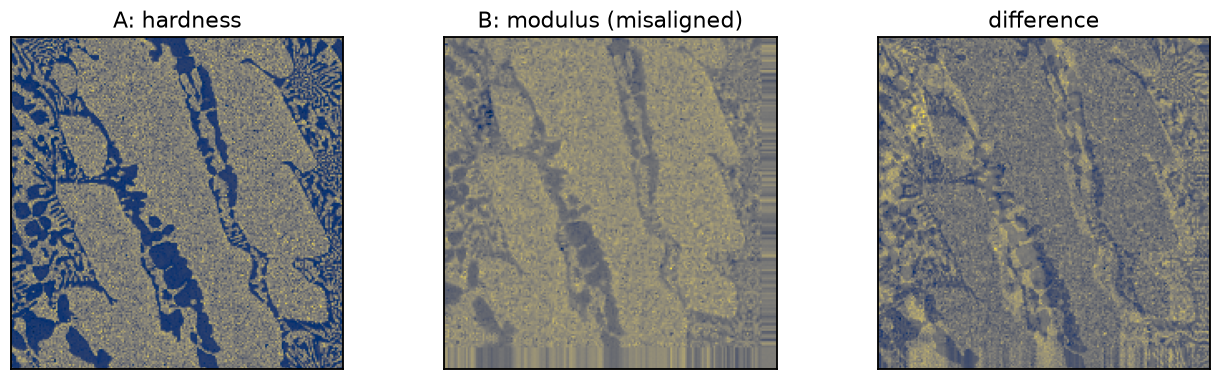

In [4]:
true_angle, true_shift = 6.0, (12, -8)          # ground truth: 6 deg, shift (row, col) in px
B = rotate(B0, true_angle, order=1, mode="reflect", preserve_range=True)
B = nd_shift(B, true_shift, order=1, mode="nearest")
B = B + np.random.default_rng(0).normal(0, 0.05 * B.std(), B.shape)   # measurement noise
print("NCC after misalignment:", round(ncc(A, B), 3), " (was ~", round(ncc(A, B0), 2), ")")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for a, (img, t) in zip(ax, [(A, "A: hardness"), (B, "B: modulus (misaligned)"),
                            (z(A) - z(B), "difference")]):
    im = a.imshow(img, origin="lower", cmap="cividis"); a.set_title(t)
    a.set_xticks([]); a.set_yticks([])
fig.tight_layout()

*🖼 **Figure.** Once B is rotated and shifted, the two maps no longer line up and the difference image is a mess. Our job: recover the transform that undoes this.*

## 3 · Recover the transform

A **rigid transform** = rotation + translation. We try a few candidate **angles**; at each, the best
**translation** comes for free from **phase cross-correlation** (an FFT trick), and we keep the angle
with the highest NCC.

> 🧠 **rigid transform**: a move that only rotates and slides an image (no stretching). Adding scale/shear makes it an *affine* transform (same idea, more parameters).

> 🧠 **phase cross-correlation**: a fast Fourier-transform method that finds the shift between two images directly, without trying every offset by hand.

> ✅ **What to look for:** the **recovered angle and shift matching the ground truth** (6°, (12, −8)), and the NCC jumping back up (~0.7).

In [5]:
best = (-1, 0.0, (0, 0), None)                   # (score, angle, shift, aligned image)
for ang in np.arange(-12, 12.1, 1.0):            # search a range of angles
    Br = rotate(B, -ang, order=1, mode="reflect", preserve_range=True)   # undo candidate rotation
    sh, _, _ = phase_cross_correlation(A, Br, upsample_factor=10)        # best translation for this angle
    Ba = nd_shift(Br, sh, order=1, mode="nearest")
    s = ncc(A, Ba)
    if s > best[0]: best = (s, ang, tuple(np.round(sh, 1)), Ba)
score, ang, sh, B_reg = best
print(f"recovered angle = {ang:.1f} deg (true {true_angle}),  shift = {sh} (true {true_shift})")
print(f"NCC: misaligned {ncc(A, B):.2f}  ->  registered {score:.2f}")

recovered angle = 6.0 deg (true 6.0),  shift = (np.float64(-11.1), np.float64(9.1)) (true (12, -8))
NCC: misaligned 0.18  ->  registered 0.71


> ✅ **What to look for:** an overlay of the two maps after registration (they line up) and a tight point-to-point correlation cloud.

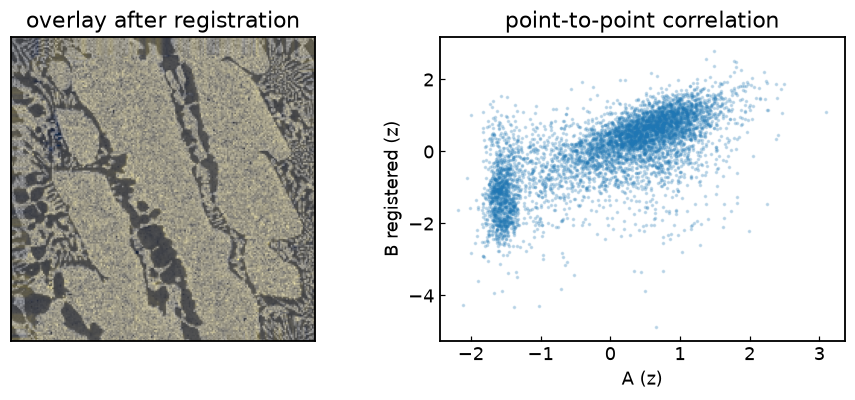

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.8))
ax[0].imshow(A, origin="lower", cmap="Greys_r")
ax[0].imshow(B_reg, origin="lower", cmap="cividis", alpha=0.5)      # semi-transparent overlay
ax[0].set_title("overlay after registration"); ax[0].set_xticks([]); ax[0].set_yticks([])
ax[1].scatter(z(A).ravel()[::7], z(B_reg).ravel()[::7], s=2, alpha=0.2)
ax[1].set_xlabel("A (z)"); ax[1].set_ylabel("B registered (z)"); ax[1].set_title("point-to-point correlation")
fig.tight_layout()

*🖼 **Figure.** After registration the maps overlay well and the scatter tightens along the diagonal. High hardness now coincides with high modulus, point for point.*

## 4 · Point-to-point agreement

Turn each aligned map into a **two-phase label** (hard vs soft, split at the median) and
cross-tabulate. The **agreement %**, **confusion matrix** and **Dice** score are exactly what you
report for a multimodal correlation.

> 🧠 **Dice score**, an overlap score for the hard phase: 1.0 = the two maps mark exactly the same pixels as 'hard', 0 = no overlap.

> ✅ **What to look for:** an agreement around **80%** and a Dice around **0.8**, plus a confusion matrix that is strong on the diagonal.

point-to-point agreement = 79.7%   hard-phase Dice = 0.80


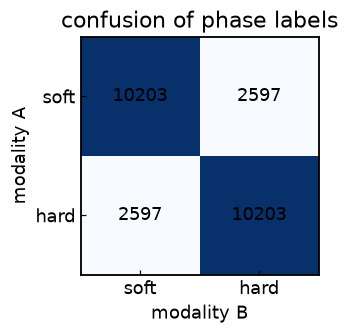

In [7]:
crop = (slice(20, 180), slice(20, 180))          # ignore the rotation border
la = (A[crop] > np.median(A[crop])).astype(int)  # phase label from map A
lb = (B_reg[crop] > np.median(B_reg[crop])).astype(int)  # phase label from registered map B
agree = float((la == lb).mean()) * 100
cm = np.array([[int(((la == i) & (lb == j)).sum()) for j in (0, 1)] for i in (0, 1)])
dice = 2 * cm[1, 1] / (2 * cm[1, 1] + cm[0, 1] + cm[1, 0])
print(f"point-to-point agreement = {agree:.1f}%   hard-phase Dice = {dice:.2f}")

fig, ax = plt.subplots(figsize=(3.4, 3.2)); im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["soft", "hard"]); ax.set_yticks([0, 1], ["soft", "hard"])
ax.set_xlabel("modality B"); ax.set_ylabel("modality A")
for (i, j), v in np.ndenumerate(cm): ax.text(j, i, f"{v}", ha="center", va="center")
ax.set_title("confusion of phase labels"); fig.tight_layout()

*🖼 **Figure.** The diagonal cells (both maps agree 'soft' or both 'hard') dominate. Agreement % and Dice are the honest, quantitative output of a correlative workflow (no eyeballing).*

### ✅ Self-check
These asserts confirm the key numbers above look right. Change something that breaks them and the next cell raises an `AssertionError`, exactly the early warning you want.

In [8]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert abs(ang - true_angle) <= 2, "the recovered rotation should match the known one"
assert agree > 70, "after registration the two maps should agree well"
print("self-check passed ✓ — the transform was recovered")

self-check passed ✓ — the transform was recovered


## ✅ Recap
- **Register first, compare second:** NCC scores overlap, phase cross-correlation recovers the translation, and a small **angle search** handles rotation.
- After alignment, **agreement %**, a **confusion matrix** and **Dice** quantify how well two modalities tell the same story.
- This is the real mechanics↔microstructure correlation method, shown here on the hardness and modulus channels of one map.

## 🔧 Try it yourself
Experiment a little. After each change, re-run the cell:
1. Change `true_angle` to 15° (and widen the search range to ±20°). Does the method still recover it?
2. Increase the noise level from `0.05` to `0.20` of the std. At what point does registration start to fail?
3. Register `duplex_2um`'s H and E channels instead of Al–Cu. Is the agreement higher or lower?

## 🩹 Common errors & fixes
- **Recovered angle is wrong** → widen the `np.arange(-12, 12.1, 1.0)` search range or use a finer step.
- **`ModuleNotFoundError: skimage`** → `pip install scikit-image`.
- **Agreement looks low** → make sure you cropped out the rotation border (the `crop` slice) before comparing.

---
**Next:** the refreshed classics: **`10_cnn_mnist`**, **`11_popin_detection`**, **`12_regression_curvefitting`**.